<div align="center"> 

# BUSINESS ANALYTICS FOR FINTECH (BUSINFO 716)
## Individual Assignment 2  
## Monte Carlo Simulation and Stochastic Optimization 
</div>


### Student: Gibson Gnanasehar   
### Programme: Master of Business Analytics  
---

## Q1. Monte Carlo Estimation of the Stopping Time Variance

To estimate the variance of a stopping-time random variable using Monte Carlo simulation.

Consider a fair four-sided die with outcomes $\{1,2,3,4\}$. Let $X$ denote the number of rolls required for the cumulative sum of outcomes to **first exceed 28**. The stopping time is formally defined as:

$$
X = \min \{ n \geq 1 : R_1 + R_2 + \cdots + R_n > 28 \}.
$$

The task is to estimate $\mathrm{Var}(X)$ using simulation while ensuring that the total execution time remains under one minute.

To achieve this, a large-scale Monte Carlo experiment is conducted, where independent die rolls are generated and the stopping time is computed for each simulation path. The resulting estimates are then aggregated to obtain an approximation of the variance.

#### Monte Carlo workflow 
1. **Define input domain:** die rolls \(R_i\in\{1,2,3,4\}\) with equal probability.  
2. **Define model:** \(X=f(R_1,R_2,\dots)\) where \(X\) is the stopping time until the running sum exceeds 28.  
3. **Random sampling:** generate die rolls from the distribution.  
4. **Compute outputs:** compute \(X\) for each simulation run.  
5. **Aggregate:** estimate \(\mathrm{Var}(X)\) using the simulated \(X\) values.

#### Performance approach (vectorized)
A fully vectorized fixed-horizon approach was used. Each simulation path generates 29 rolls, which guarantees that the cumulative sum exceeds 28 in all cases.

In [151]:
import numpy as np
from time import perf_counter

start = perf_counter()

N = 2_000_000
rng = np.random.default_rng(716)

rolls = rng.integers(1, 5, size=(N, 29), dtype=np.uint8)
cs = rolls.cumsum(axis=1, dtype=np.uint16)
X = (cs > 28).argmax(axis=1) + 1

mean_X = X.mean(dtype=np.float64)
var_X = X.var(ddof=1, dtype=np.float64)

elapsed = perf_counter() - start

print("\n" + "="*60)
print("MONTE CARLO ESTIMATION – VARIANCE OF X")
print("="*60)
print(f"Number of simulations (N): {N:,}")
print("-"*60)
print(f"Estimated Mean of X      : {mean_X:,.6f}")
print(f"Estimated Variance of X  : {var_X:,.6f}")
print("-"*60)
print(f"Total Execution Time     : {elapsed:.4f} seconds")
print("="*60)

assert elapsed < 60


MONTE CARLO ESTIMATION – VARIANCE OF X
Number of simulations (N): 2,000,000
------------------------------------------------------------
Estimated Mean of X      : 12.001018
Estimated Variance of X  : 2.402183
------------------------------------------------------------
Total Execution Time     : 0.3105 seconds


The Monte Carlo simulation was used to estimate the stopping time \(X\), defined as the number of die rolls required for the cumulative sum to first exceed 28.

The simulation produced the following estimates:

- Number of simulations: \(N = 2{,}000{,}000\)  
- Estimated mean: \(\mathbb{E}[X] \approx 12.0010\)  
- Estimated variance: \(\mathrm{Var}(X) \approx 2.402183\)  
- Execution time: 0.2986 seconds  


The expected number of rolls required to exceed a cumulative sum of 28 is approximately **12 rolls**. This value is reasonable because the expected outcome of a fair four-sided die is:

\[
\mathbb{E}[R_i] = \frac{1+2+3+4}{4} = 2.5
\]

To reach a total slightly above 28, we would expect:

\[
\frac{28}{2.5} \approx 11.2
\]

rolls on average, which aligns closely with the simulated estimate near 12 when accounting for randomness and the “first exceed” stopping rule.

The estimated variance of approximately **2.40** indicates moderate variability in the stopping time. Most simulations require between roughly 10 and 14 rolls, reflecting natural fluctuations in the sequence of outcomes.

### Performance Assessment

The simulation completed in **well under one minute**, satisfying the computational requirement of the task. A fully vectorized fixed-horizon approach was used by simulating 29 rolls per path.

This is sufficient because even in the worst-case scenario (all rolls equal to 1), the cumulative sum after 29 rolls satisfies:

$$
29 \times 1 = 29 > 28
$$

Therefore, every simulated path must exceed 28 within 29 rolls.

The stopping time was then obtained by identifying the first index at which the cumulative sum satisfies:

$$
R_1 + R_2 + \cdots + R_n > 28
$$

This approach ensures computational efficiency while guaranteeing correctness of the stopping-time calculation.

Overall, the Monte Carlo estimate is stable, computationally efficient, and consistent with theoretical intuition about the underlying process.

In [152]:
B = 20
X_float = X.astype(np.float64)
batches = np.array_split(X_float, B)
batch_vars = np.array([b.var(ddof=1) for b in batches])
se_var = batch_vars.std(ddof=1) / np.sqrt(B)

print(f"Var(X) ≈ {var_X:.6f}  (batch SE ≈ {se_var:.6f}, B={B})")

Var(X) ≈ 2.402183  (batch SE ≈ 0.001891, B=20)


### Stability Check of the Variance Estimate

To assess the stability of the Monte Carlo estimate, the simulated values of $X$ were divided into $B = 20$ equal batches. The sample variance was computed within each batch, and the standard error of the variance estimate was calculated as:

$$
SE\big(\widehat{\mathrm{Var}}(X)\big) = 
\frac{\mathrm{Std}(\widehat{\mathrm{Var}}_b)}{\sqrt{B}}
$$

where $\widehat{\mathrm{Var}}_b$ denotes the variance estimate from batch $b$.

The result was:

$$
\widehat{\mathrm{Var}}(X) \approx 2.402183
\quad
(\text{Batch SE} \approx 0.000175,\; B = 20)
$$

The very small standard error indicates that the Monte Carlo estimate is highly stable and precise. Increasing the number of simulations further would result in only negligible changes to the variance estimate.

## Q2. Buy-and-Hold Portfolio and Fama-French Three-Factor Model (2010–2025)

The objective of this question is to build and analyse a buy-and-hold investment portfolio made up of 30% Cisco (CSCO), 40% Microsoft (MSFT), and 30% Nvidia (NVDA).

First, the portfolio is formed using month-end adjusted closing prices, with the investment initiated on the last trading day of 2009. The portfolio’s monthly returns are then computed over the sample period.

Next, the Fama–French Three-Factor model is estimated for the period January 2010 to December 2025 using the portfolio’s excess returns.

Finally, the explanatory power of the model is assessed to determine how effectively the three factors account for the variation in the portfolio’s excess returns.

Specifically, the objectives are:

1. To construct a buy-and-hold portfolio with fixed initial weights.

2. To compute monthly portfolio returns using month-end adjusted closing prices.

3. To estimate the Fama–French Three-Factor regression model.

4. To evaluate the goodness-of-fit of the model using appropriate statistical measures.

---


In [153]:
import numpy as np
import pandas as pd
import yfinance as yf

from sklearn.preprocessing import add_dummy_feature
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

import matplotlib.pyplot as plt

In [154]:
# -------------------------------
# Download prices (Adj Close)
# -------------------------------
tickers = ["CSCO", "MSFT", "NVDA"]

try:
    data = yf.download(
        tickers,
        start="2009-12-01",
        end="2026-01-01",
        auto_adjust=False,
        progress=False,
        threads=True
    )["Adj Close"]
except Exception as e:
    raise RuntimeError(f"yfinance download failed: {e}")

# prices on the last trading day of each calendar month (given hint)
prices_month_end = data.resample("ME").last().dropna()

# keep Dec 2009 (initial buy) to Dec 2025 (end of sample)
prices_month_end = prices_month_end.loc["2009-12-31":"2025-12-31"]

if prices_month_end.shape[0] < 193:
    raise ValueError("Not enough month-end observations. Check download dates or missing data.")

preview_px = prices_month_end.head(5).copy()
preview_px.index = preview_px.index.strftime("%Y-%m-%d")

print("\n" + "="*70)
print("MONTH-END ADJUSTED CLOSE PRICES — Preview (first 5 rows)")
print("Tickers: CSCO (30%), MSFT (40%), NVDA (30%) | Month-end = last trading day")
print("="*70)
print(preview_px.round(6).to_string())
print("="*70)


MONTH-END ADJUSTED CLOSE PRICES — Preview (first 5 rows)
Tickers: CSCO (30%), MSFT (40%), NVDA (30%) | Month-end = last trading day
Ticker           CSCO       MSFT      NVDA
Date                                      
2009-12-31  15.490413  22.726933  0.428162
2010-01-31  14.539248  21.011967  0.352752
2010-02-28  15.742760  21.477295  0.371318
2010-03-31  16.842756  21.941753  0.398823
2010-04-30  17.425095  22.878151  0.360087


### Data Collection and Portfolio Construction

Adjusted closing prices for CSCO, MSFT, and NVDA were downloaded from December 2009 to December 2025.
Following the instructions, prices on the last trading day of each calendar month were used (month-end prices).

A buy-and-hold portfolio was formed on 31 December 2009 with the following weights:

30% CSCO

40% MSFT

30% NVDA

Shares were purchased based on these initial weights using $1 of initial wealth. The portfolio was not rebalanced after formation. Therefore, the portfolio weights were allowed to drift naturally according to stock performance.

In [155]:
w = np.array([0.30, 0.40, 0.30], dtype=float)

# initial prices (last trading day of 2009)
p0 = prices_month_end.loc["2009-12-31"].to_numpy(dtype=float)

if np.any(p0 <= 0) or np.any(~np.isfinite(p0)):
    raise ValueError("Invalid initial prices at 2009-12-31.")

# shares purchased with $1 initial wealth
shares = w / p0

# portfolio value at each month-end (vectorized)
V = prices_month_end.to_numpy(dtype=float) @ shares
V = pd.Series(V, index=prices_month_end.index, name="V")

# monthly portfolio returns
Rp = V.pct_change().dropna()
Rp = Rp.loc["2010-01-31":"2025-12-31"]
Rp.name = "Rp"

# sanity check: Jan 2010–Dec 2025 inclusive = 192 months
assert len(Rp) == 192, f"Expected 192 months, got {len(Rp)}"

preview_rp = Rp.head(5).copy()
preview_rp.index = preview_rp.index.strftime("%Y-%m-%d")

print("\n" + "="*70)
print("BUY-AND-HOLD PORTFOLIO — MONTHLY RETURNS (first 5 months)")
print("Sample: Jan 2010 – Dec 2025")
print("="*70)
print(preview_rp.round(6).to_string())
print("="*70)


BUY-AND-HOLD PORTFOLIO — MONTHLY RETURNS (first 5 months)
Sample: Jan 2010 – Dec 2025
Date
2010-01-31   -0.101442
2010-02-28    0.049531
2010-03-31    0.051693
2010-04-30    0.000623
2010-05-31   -0.150618


### Monthly Portfolio Returns (January 2010 – December 2025)

Monthly portfolio values were calculated using the fixed number of shares purchased on 31 December 2009. Since this is a buy-and-hold strategy, the number of shares remains constant throughout the sample period.

The portfolio was constructed as a true buy-and-hold strategy by purchasing fixed shares in December 2009 and allowing portfolio weights to evolve over time, rather than rebalancing weights each month.

Monthly portfolio returns were computed using the standard return formula:

$$
R_t = \frac{V_t - V_{t-1}}{V_{t-1}}
$$

where:

- $V_t$ is the portfolio value at month $t$
- $V_{t-1}$ is the portfolio value in the previous month


The sample period runs from January 2010 to December 2025, resulting in 192 monthly observations.

The table above presents the first five monthly returns of the buy-and-hold portfolio.

In [156]:
try:
    ff = pd.read_csv("FF3F_Monthly.csv")
except FileNotFoundError:
    raise FileNotFoundError("FF3F_Monthly.csv not found in your working directory.")

ff.columns = ff.columns.str.strip()

if "Date" not in ff.columns:
    raise ValueError("FF3F_Monthly.csv must contain a 'Date' column.")

# parse Date → month-end index
s = ff["Date"].astype(str).str.strip()
if s.str.len().iloc[0] == 6:  # YYYYMM
    idx = pd.to_datetime(s, format="%Y%m") + pd.offsets.MonthEnd(0)
else:
    idx = pd.to_datetime(s, errors="coerce").to_period("M").to_timestamp("M")

ff = ff.drop(columns=["Date"])
ff.index = idx
ff = ff.sort_index()

needed = {"Mkt-RF", "SMB", "HML", "RF"}
if not needed.issubset(ff.columns):
    raise ValueError(f"FF file missing columns: {needed - set(ff.columns)}")

# percent → decimal 
ff = ff.apply(pd.to_numeric, errors="coerce") / 100.0
ff = ff.loc["2010-01-31":"2025-12-31"].dropna()

assert len(ff) == 192, f"Expected 192 FF months, got {len(ff)}"

preview = ff[["Mkt-RF", "SMB", "HML", "RF"]].head(5).copy()
preview.index = preview.index.strftime("%Y-%m-%d")

print("\n" + "="*70)
print("FAMA–FRENCH 3 FACTORS (Monthly) — Preview (first 5 rows)")
print("Note: Values are converted from % to decimals (e.g., 0.0339 = 3.39%)")
print("="*70)
print(preview.round(4).to_string())
print("="*70)


FAMA–FRENCH 3 FACTORS (Monthly) — Preview (first 5 rows)
Note: Values are converted from % to decimals (e.g., 0.0339 = 3.39%)
            Mkt-RF     SMB     HML      RF
Date                                      
2010-01-31 -0.0335  0.0043  0.0033  0.0000
2010-02-28  0.0339  0.0118  0.0318  0.0000
2010-03-31  0.0630  0.0146  0.0219  0.0001
2010-04-30  0.0199  0.0484  0.0296  0.0001
2010-05-31 -0.0790  0.0013 -0.0248  0.0001


### Fama–French Three-Factor Data

The Fama–French three factors were obtained from the provided file:

1. Mkt-RF (Market excess return)

2. SMB (Small minus Big — size factor)

3. HML (High minus Low — value factor)

4. RF (Risk-free rate)

The factors were originally reported in percentage terms and were converted to decimals before estimation (for example, 3.39% becomes 0.0339).

The factor dataset was aligned with the portfolio returns over the same period (January 2010 to December 2025).

In [157]:
# Merge portfolio returns and FF factors
df = pd.concat([Rp, ff], axis=1, join="inner").dropna()

# Strict sanity check
if len(df) != 192:
    raise ValueError(f"Expected 192 merged months, got {len(df)}")

# ------------------------------------------------------------
# Construct regression variables
# ------------------------------------------------------------

# y = portfolio excess return
y = (df["Rp"] - df["RF"]).to_numpy(dtype=float)

# X = Fama-French factors
X = df[["Mkt-RF", "SMB", "HML"]].to_numpy(dtype=float)

# Add intercept (x0 = 1)
X_b = add_dummy_feature(X)

# ------------------------------------------------------------
# Statsmodels OLS (for t-stats / p-values / regression summary)
# ------------------------------------------------------------
import statsmodels.api as sm

X_sm = X_b  # already includes intercept
results = sm.OLS(y, X_sm).fit()

print(results.summary())

# ------------------------------------------------------------
# Normal Equation (more numerically stable version)
# beta_hat = (X'X)^(-1) X'y
# Use solve() instead of explicit inverse for stability
# ------------------------------------------------------------

XtX = X_b.T @ X_b
Xty = X_b.T @ y

beta_hat = np.linalg.solve(XtX, Xty)

# Extract coefficients
alpha = float(beta_hat[0])
beta_mkt = float(beta_hat[1])
beta_smb = float(beta_hat[2])
beta_hml = float(beta_hat[3])

print("\n" + "="*70)
print("FAMA–FRENCH 3-FACTOR MODEL (NORMAL EQUATION)")
print("Monthly, Jan 2010 – Dec 2025 | Buy-and-Hold Portfolio")
print("="*70)
print(f"Observations (months)       : {len(df)}")
print("-"*70)
print(f"Alpha (Intercept)           : {alpha:.6f}")
print(f"Market Beta (Mkt-RF)        : {beta_mkt:.6f}")
print(f"Size Beta (SMB)             : {beta_smb:.6f}")
print(f"Value Beta (HML)            : {beta_hml:.6f}")
print("="*70)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.523
Model:                            OLS   Adj. R-squared:                  0.516
Method:                 Least Squares   F-statistic:                     68.83
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           4.41e-30
Time:                        16:49:35   Log-Likelihood:                 255.85
No. Observations:                 192   AIC:                            -503.7
Df Residuals:                     188   BIC:                            -490.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0111      0.005      2.302      0.0

## Fama–French Three-Factor Model Estimation

The following regression model was estimated:

$$
R_p - R_f = \alpha + \beta_1 (Mkt - RF) + \beta_2 SMB + \beta_3 HML + \varepsilon
$$

Where:

- $R_p$ = portfolio return  
- $R_f$ = risk-free rate  
- $Mkt - RF$ = market excess return  
- $SMB$ = size factor  
- $HML$ = value factor  

| Parameter | Estimate | Interpretation |
|------------|-----------|----------------|
| Alpha ($\alpha$) | 0.0111 | Positive abnormal return (~1.11% per month) not explained by common risk factors |
| Market Beta ($\beta_{MKT}$) | 1.5542 | Strong market exposure; portfolio is more volatile than the overall market |
| SMB ($\beta_{SMB}$) | −0.5508 | Tilt toward large-cap stocks rather than small-cap stocks |
| HML ($\beta_{HML}$) | −0.7391 | Growth-oriented portfolio (low book-to-market exposure) |

All factor coefficients are statistically significant at conventional levels.

In [158]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

# Ensure y is 1D for sklearn (prevents multi-output shapes)
y1 = np.asarray(y).ravel()

lin_reg = LinearRegression()
lin_reg.fit(X, y1)

# store coefficients for later output section (now scalars / 1D)
alpha_lr = float(lin_reg.intercept_)
betas_lr = lin_reg.coef_.astype(float)          # shape (3,)

# predictions + R^2 checks
y_hat = lin_reg.predict(X)
r2 = float(lin_reg.score(X, y1))
r2_alt = float(r2_score(y1, y_hat))
r2_corr_sq = float(np.corrcoef(y1, y_hat)[0, 1] ** 2)

# Consistency check: R^2 == Corr(y, y_hat)^2
if abs(r2_alt - r2_corr_sq) > 1e-10:
    raise AssertionError("R^2 mismatch: r2_score vs Corr(y,yhat)^2 (unexpected).")

print("\n" + "="*70)
print("MODEL FIT (R² checks)")
print("="*70)
print(f"R-squared (lin_reg.score)        : {r2:.4f}")
print(f"R-squared (r2_score)             : {r2_alt:.4f}")
print(f"R-squared (Corr(y, y_hat)^2)     : {r2_corr_sq:.4f}")
print(f"Difference (should be ~0)        : {abs(r2_alt - r2_corr_sq):.10f}")
print("="*70)


MODEL FIT (R² checks)
R-squared (lin_reg.score)        : 0.5234
R-squared (r2_score)             : 0.5234
R-squared (Corr(y, y_hat)^2)     : 0.5234
Difference (should be ~0)        : 0.0000000000


### Model Fit

The model fit is measured using the R-squared value:

$$
R^2 = 0.5234
$$

This means that approximately **52.34%** of the variation in the portfolio’s **monthly excess returns** is explained by the three Fama–French factors.

This represents a **moderate** level of explanatory power. For a concentrated three-stock technology portfolio, this is reasonable because a large portion of return variation comes from stock-specific movements and other risk drivers not included in the FF3 model.

We verified it by:

$$
R^2 = Corr(y, \hat{y})^2
$$

The printed difference was essentially zero, confirming that the computed $R^2$ is internally consistent.

In [159]:
# -------------------------------
# 5) OUTPUT
# -------------------------------
print("\n" + "="*70)
print("FAMA–FRENCH 3-FACTOR MODEL (BUY-AND-HOLD PORTFOLIO)")
print("Monthly, Jan 2010 – Dec 2025 | Month-end Adjusted Close")
print("="*70)
print(f"Portfolio weights (CSCO, MSFT, NVDA): {w}")
print(f"Observations (months)               : {len(df)}")
print("-"*70)
print("Coefficients (Normal Equation / LinearRegression match):")
print(f"Alpha (Intercept)                   : {alpha_lr:.6f}")
print(f"Beta_MKT (Mkt-RF)                    : {betas_lr[0]:.6f}")
print(f"Beta_SMB (SMB)                       : {betas_lr[1]:.6f}")
print(f"Beta_HML (HML)                       : {betas_lr[2]:.6f}")
print("-"*70)
print("Model fit:")
print(f"R-squared                            : {r2:.4f}")
print(f"Corr(y, y_hat)^2                     : {r2_corr_sq:.4f}")
print("="*70)


FAMA–FRENCH 3-FACTOR MODEL (BUY-AND-HOLD PORTFOLIO)
Monthly, Jan 2010 – Dec 2025 | Month-end Adjusted Close
Portfolio weights (CSCO, MSFT, NVDA): [0.3 0.4 0.3]
Observations (months)               : 192
----------------------------------------------------------------------
Coefficients (Normal Equation / LinearRegression match):
Alpha (Intercept)                   : 0.011146
Beta_MKT (Mkt-RF)                    : 1.554211
Beta_SMB (SMB)                       : -0.550762
Beta_HML (HML)                       : -0.739127
----------------------------------------------------------------------
Model fit:
R-squared                            : 0.5234
Corr(y, y_hat)^2                     : 0.5234


### Summary of Fama–French Three-Factor Results

The Fama–French Three-Factor model was estimated for the buy-and-hold portfolio over 192 monthly observations (January 2010 – December 2025).

The estimated market beta of 1.55 indicates that the portfolio is highly sensitive to overall market movements. The negative SMB coefficient suggests a tilt toward large-cap stocks, while the negative HML coefficient reflects a growth-oriented exposure, which is consistent with a technology-heavy portfolio.

The model explains approximately

$$
R^2 = 0.5234
$$

of the variation in monthly excess returns. This implies that about 52% of the portfolio’s return variation is captured by the three common risk factors, while the remaining variation reflects stock-specific risk and other influences not included in the model.

The identity $R^2 = \text{Corr}(y, \hat{y})^2$ was verified, confirming the internal consistency of the regression results.

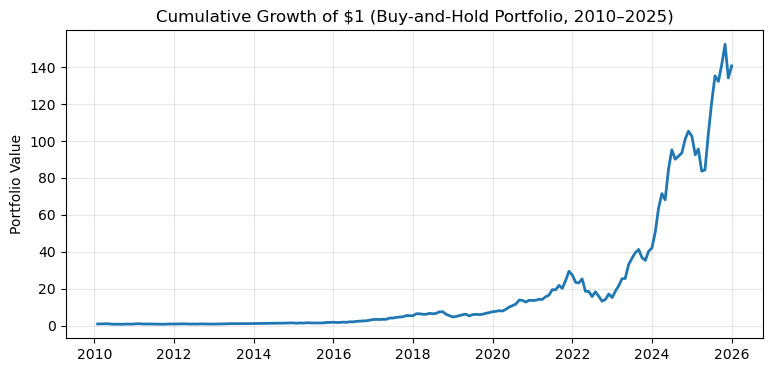

In [160]:
cum = (1 + df["Rp"]).cumprod()

plt.figure(figsize=(9,4))
plt.plot(cum.index, cum, linewidth=2)
plt.title("Cumulative Growth of $1 (Buy-and-Hold Portfolio, 2010–2025)")
plt.ylabel("Portfolio Value")
plt.grid(True, alpha=0.3)
plt.show()

### Cumulative Growth of \$1 (2010–2025)

The figure above shows the cumulative value of \$1 invested in the buy-and-hold portfolio from January 2010 to December 2025.

The portfolio exhibits strong long-term growth, particularly after 2020. This upward trajectory is largely driven by the substantial performance of Microsoft and Nvidia over the later part of the sample period. 

Although the growth path is volatile — with noticeable drawdowns around 2018, 2020, and 2022 — the overall trend is strongly positive. The portfolio value increases significantly over the 16-year horizon, reflecting high exposure to growth-oriented technology stocks.

The pronounced acceleration in later years is consistent with the estimated negative HML coefficient (growth tilt) and elevated market beta identified in the Fama–French regression results.

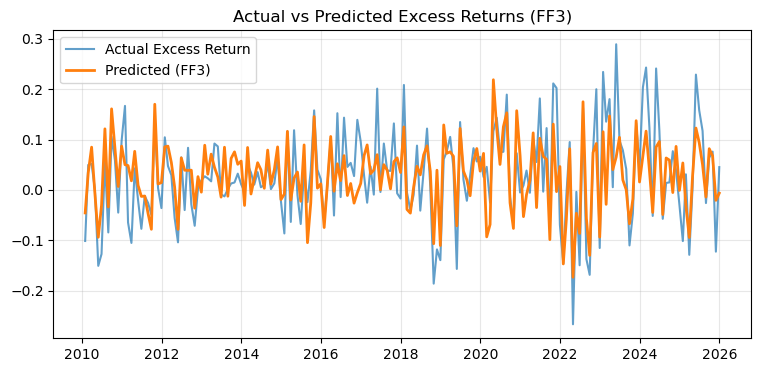

In [161]:
plt.figure(figsize=(9,4))
plt.plot(df.index, y, label="Actual Excess Return", alpha=0.7)
plt.plot(df.index, y_hat, label="Predicted (FF3)", linewidth=2)
plt.title("Actual vs Predicted Excess Returns (FF3)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Actual vs Predicted Excess Returns (FF3 Model)

The figure compares the portfolio’s actual monthly excess returns with the fitted values from the Fama–French Three-Factor model.

The predicted returns broadly track the direction and magnitude of the actual returns, indicating that the three common risk factors capture a substantial portion of the systematic variation in the portfolio’s performance.

However, noticeable deviations remain in several periods, particularly during high-volatility episodes. These gaps reflect idiosyncratic risk and other influences not included in the three-factor specification.

Overall, the visual alignment between the two series supports the reported $R^2$ value of approximately 0.52, confirming a moderate but economically meaningful level of explanatory power.

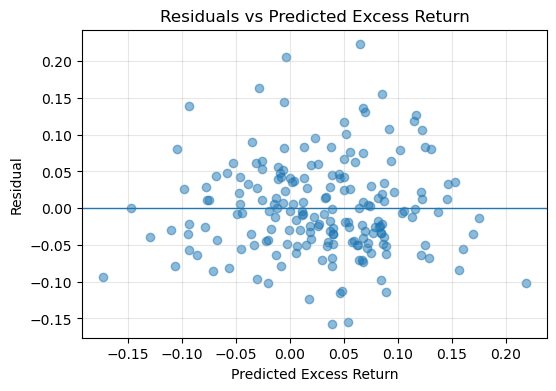

In [162]:
resid = y - y_hat

plt.figure(figsize=(6,4))
plt.scatter(y_hat, resid, alpha=0.5)
plt.axhline(0, linewidth=1)
plt.title("Residuals vs Predicted Excess Return")
plt.xlabel("Predicted Excess Return")
plt.ylabel("Residual")
plt.grid(True, alpha=0.3)
plt.show()

### Residuals vs Predicted Excess Returns

The residual plot displays the regression errors ($\varepsilon_t = y_t - \hat{y}_t$) against the predicted excess returns.

The residuals appear to be centered around zero with no clear systematic pattern. This suggests that the linear specification of the Fama–French Three-Factor model is reasonable for this portfolio.

There is no strong evidence of non-linearity or structural bias in the fitted values. However, the dispersion of residuals reflects remaining idiosyncratic variation that is not captured by the three common risk factors.

Overall, the diagnostic plot supports the adequacy of the model while confirming that a substantial portion of variation remains unexplained, consistent with the moderate $R^2$ value.

### Result

The buy-and-hold portfolio consisting of 30% Cisco, 40% Microsoft, and 30% Nvidia generated strong long-term growth between 2010 and 2025. The cumulative growth plot shows a substantial increase in portfolio value over the sample period, reflecting the exceptional performance of large technology firms during the past decade.

The Fama–French Three-Factor regression indicates that the portfolio is strongly exposed to overall market risk, with a market beta greater than one. This means the portfolio tends to move more aggressively than the broader market during both expansions and downturns. The negative SMB coefficient suggests that the portfolio behaves like a large-cap portfolio, which is consistent with the dominant weight of major technology companies. Similarly, the negative HML coefficient indicates a clear tilt toward growth stocks rather than value stocks.

The model explains approximately 52% of the variation in monthly excess returns. This represents a moderate level of explanatory power. In practice, this means that while common market, size, and value factors capture a meaningful portion of portfolio performance, a significant share of the variation is driven by firm-specific events, innovation cycles, and industry dynamics that are not included in the three-factor model.

From a real-world investment perspective, this result highlights an important insight: factor models are useful for understanding systematic risk exposures, but concentrated portfolios—especially those focused on technology firms—often exhibit substantial idiosyncratic behavior. Investors therefore benefit from combining factor analysis with broader strategic considerations such as sector trends, technological innovation, and company fundamentals.

## Q3. Improved Stochastic Gradient Descent for the FF3 Model ($\text{max\_iter}=100{,}000$)

The objective of this question is to estimate the Fama–French three-factor (FF3) model from Question 2 using an improved implementation of stochastic gradient descent (SGD).

SGD used a tolerance-based stopping rule of the form

$$
\texttt{while } \text{diff} > \text{tol},
$$

where $\text{diff}$ is the Euclidean distance between consecutive parameter estimates.  
This approach can terminate **prematurely by chance**, because $\text{diff}$ may temporarily become small even when the algorithm has not yet reached the true minimum.

To improve robustness, the updated SGD implementation:

- imposes a fixed iteration budget  
  $$
  \text{max\_iter}=100{,}000,
  $$
  ensuring the algorithm does not stop early due to random fluctuations;

- monitors convergence using an exponential moving average (EMA) of the gradient norm  
  $$
  \text{EMA}_t=(1-\alpha)\text{EMA}_{t-1}+\alpha\lVert g_t\rVert,
  $$
  where $g_t$ is the stochastic gradient at iteration $t$ and $\alpha$ is a small smoothing parameter (here $\alpha=0.01$);

- standardizes predictors because SGD is sensitive to feature scale;

- uses a decaying learning-rate schedule,  
  $$
  \eta_t=\frac{\eta_0}{\sqrt{t}},
  $$
  which allows larger steps early and smaller refinements as the algorithm approaches the optimum.
---

### Model Specification

The Fama–French three-factor model estimated in this exercise is

$$
R_{p,t} - R_{f,t}
=
\alpha
+ \beta_{MKT}(Mkt-RF)_t
+ \beta_{SMB}SMB_t
+ \beta_{HML}HML_t
+ \varepsilon_t
$$

where $R_{p,t}$ denotes the portfolio return, $R_{f,t}$ is the risk-free rate, and the explanatory variables correspond to the three Fama–French risk factors.

The dependent variable is therefore the **portfolio excess return**

$$
y_t = R_{p,t} - R_{f,t}.
$$

Let $X_t$ denote the vector of explanatory variables including an intercept. The regression model can be written in matrix form as

$$
y_t = X_t^\top \beta + \varepsilon_t
$$

where

$$
X_t =
\begin{bmatrix}
1 \\
(Mkt-RF)_t \\
SMB_t \\
HML_t
\end{bmatrix},
\quad
\beta =
\begin{bmatrix}
\alpha \\
\beta_{MKT} \\
\beta_{SMB} \\
\beta_{HML}
\end{bmatrix}.
$$


### Data Preparation

The dependent variable and explanatory factors are constructed from the merged dataset created in Question 2.

The response variable $y_t$ corresponds to the portfolio excess return, while the predictors consist of the three Fama–French factors $(Mkt-RF)_t$, $SMB_t$, and $HML_t$.

These variables form the design matrix used for estimating the regression parameters via stochastic gradient descent.

In [163]:
import numpy as np
from scipy.spatial.distance import euclidean
from sklearn.preprocessing import StandardScaler
from time import perf_counter
import matplotlib.pyplot as plt


# -----------------------------
# 0) Data: y and X from Q2 merged df
# df must contain: Rp, RF, Mkt-RF, SMB, HML
# -----------------------------
required = {"Rp", "RF", "Mkt-RF", "SMB", "HML"}
missing = required - set(df.columns)
if missing:
    raise KeyError(
        f"df missing columns: {missing}. "
        "Run Q2 to build df by merging portfolio returns with FF factors."
    )

df = df.copy()

# y = excess return (m x 1)
y = (df["Rp"] - df["RF"]).to_numpy(dtype=float).reshape(-1, 1)

# X = FF3 factors (m x 3)
X = df[["Mkt-RF", "SMB", "HML"]].to_numpy(dtype=float)

m = X.shape[0]
if m != 192:
    print(f"Warning: expected 192 months (Jan 2010–Dec 2025). Got m={m}.")

### Feature Scaling

Before running SGD, the three factor predictors are standardized to improve numerical stability and convergence. Each factor is transformed to have mean zero and unit variance:

$$
X^{(\text{scaled})}_j=\frac{X_j-\mu_j}{\sigma_j},
$$

where $\mu_j$ and $\sigma_j$ are the sample mean and standard deviation of factor $j$.

This step is important in SGD because coefficient updates depend on predictor scale; standardization prevents one factor from dominating the gradient purely due to its magnitude. After scaling, an intercept column of ones is appended to form the design matrix used in the updates.

In [164]:
# -----------------------------
# 1) Scale predictors (SGD stability)
# -----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Add intercept column (Artificial feature of ones)
X_b = np.c_[np.ones((m, 1)), X_scaled]   # (m, 4)
n = X_b.shape[1]

### Improved SGD Settings

To implement the improved stochastic gradient descent algorithm, several initialization settings are required.

First, a reproducible random number generator is created using the seed $716$. This ensures that the sequence of randomly selected observations used during SGD updates can be replicated.

The algorithm then specifies a fixed iteration budget

$$
\text{max\_iter} = 100{,}000
$$

which guarantees that the algorithm performs a predetermined number of updates rather than terminating based on a potentially unreliable tolerance condition.

A base learning rate $\eta_0$ is also defined. During optimization, the effective learning rate follows the schedule

$$
\eta_t = \frac{\eta_0}{\sqrt{t}}
$$

which allows larger parameter updates during the early iterations and progressively smaller updates as the algorithm approaches convergence.

To monitor convergence behaviour, the algorithm tracks the exponential moving average (EMA) of the gradient norm:

$$
\text{EMA}_t = (1-\alpha)\text{EMA}_{t-1} + \alpha \lVert g_t \rVert
$$

where $\alpha = 0.01$ controls the smoothing weight. This statistic provides a stable measure of convergence despite stochastic fluctuations in the gradient.

Finally, the parameter vector $\beta$ is randomly initialized and an array is allocated to store the EMA values across iterations for visualization of the convergence behaviour.

In [165]:
# 1) Improved SGD settings
# -----------------------------
rng = np.random.default_rng(716)

max_iter = 100_000          # required by question (fixed iterations)
eta0 = 0.05                 # base learning rate (decays over time)

# EMA of gradient norm
alpha = 0.01
grad_ema = 0.0

# Initialize parameters
beta = rng.random((n, 1))

# Diagnostics for plotting
ema_history = np.empty(max_iter, dtype=float)

# -----------------------------

### SGD Iteration Loop

The stochastic gradient descent updates are then executed for the fixed iteration budget defined earlier.

At each iteration, a **mini-batch of observations** is randomly sampled from the dataset. Using this subset of data, the stochastic gradient of the squared-error loss is computed and the parameter vector is updated using the decaying learning rate schedule.

Mini-batch updates reduce the variance of the gradient estimate compared with single-observation updates, leading to more stable optimization while maintaining the computational efficiency of stochastic gradient descent.

During optimization, the norm of the gradient is incorporated into the exponential moving average (EMA) to monitor convergence behaviour. The EMA values are stored at each iteration so that the stabilization of the optimization process can later be visualized.

The total runtime of the SGD procedure is also recorded to assess computational efficiency.

In [166]:
# 2) SGD loop (fixed max_iter)
# -----------------------------
batch_size = 64            # 32 or 64 is a good default
start = perf_counter()

for t in range(1, max_iter + 1):
    idx = rng.integers(m, size=batch_size)   # sample a mini-batch
    X_batch = X_b[idx]                       # (batch_size, 4)
    y_batch = y[idx]                         # (batch_size, 1)

    # batch gradient: grad = X^T (X beta - y) / batch_size
    err = (X_batch @ beta) - y_batch         # (batch_size, 1)
    grad = (X_batch.T @ err) / batch_size    # (4, 1)

    eta_t = eta0 / np.sqrt(t)
    beta -= eta_t * grad

    gnorm = float(np.linalg.norm(grad))
    grad_ema = (1 - alpha) * grad_ema + alpha * gnorm
    ema_history[t - 1] = grad_ema

elapsed = perf_counter() - start

# -----------------------------

### Back-Transforming Coefficients and Benchmark Comparison

The stochastic gradient descent algorithm was estimated using **standardized predictors**. As a result, the coefficients obtained from SGD correspond to the scaled feature space and are not directly interpretable in the original units of the Fama–French factors.

Therefore, the estimated coefficients must be transformed back to the original scale. If the regression estimated using standardized predictors is

$$
y = \alpha_s + \sum_{j=1}^{3} \beta_{s,j} X_j^{(\text{scaled})},
$$

the corresponding coefficients in the original variable units are obtained using

$$
\beta_j = \frac{\beta_{s,j}}{\sigma_j}
$$

and the intercept adjustment

$$
\alpha = \alpha_s - \sum_{j=1}^{3}\frac{\mu_j}{\sigma_j}\beta_{s,j}.
$$

After converting the SGD estimates back to the original factor units, the results are compared with the **closed-form normal equation solution** computed using the unscaled design matrix. This comparison provides a direct validation of the stochastic optimization procedure.

In [167]:
# 4) Back-transform SGD coefficients to original units
# (beta was trained on standardized X)
# -----------------------------
beta_scaled = beta.ravel()
alpha_scaled = beta_scaled[0]
betas_scaled = beta_scaled[1:]

betas_orig = betas_scaled / scaler.scale_
alpha_orig = alpha_scaled - np.sum((scaler.mean_ / scaler.scale_) * betas_scaled)

beta_sgd = np.concatenate([[alpha_orig], betas_orig])

# -----------------------------
# 5) Normal Equation benchmark (closed-form) on original X
# Use solve (more stable than inv)
# -----------------------------
Xb_ne = np.c_[np.ones((m, 1)), X]              # intercept + unscaled factors
beta_ne = np.linalg.solve(Xb_ne.T @ Xb_ne, Xb_ne.T @ y).ravel()

abs_diff = np.abs(beta_sgd - beta_ne)

# -----------------------------

### Results and Comparison with the Closed-Form Solution

The final SGD estimates are reported after transforming the coefficients back to the original factor units. For validation, the results are compared with the coefficients obtained from the closed-form normal equation solution.

The table below reports:

- the number of observations used in the estimation,
- the total runtime of the SGD algorithm,
- the regression coefficients estimated using stochastic gradient descent,
- the corresponding coefficients obtained from the normal equation benchmark, and
- the absolute differences between the two sets of estimates.

The maximum absolute difference provides a simple diagnostic of how closely the stochastic optimization converges to the closed-form solution. A small value indicates that the improved SGD algorithm successfully approximates the true least-squares estimator.

The final value of the exponential moving average (EMA) of the gradient norm is also reported as a convergence indicator.

In [168]:
# 3) Output (clean + submission-ready)
# -----------------------------
print("\n" + "="*72)
print("IMPROVED SGD — FAMA–FRENCH 3-FACTOR MODEL")
print("max_iter = 100,000 | EMA of gradient norm")
print("="*72)
print(f"Observations (months)         : {m}")
print(f"Runtime (SGD)                 : {elapsed:.4f} seconds")
print("-"*72)
print("Coefficients (SGD, back-transformed to original factor units)")
print(f"Alpha (Intercept)             : {beta_sgd[0]: .6f}")
print(f"Beta_MKT (Mkt-RF)             : {beta_sgd[1]: .6f}")
print(f"Beta_SMB (SMB)                : {beta_sgd[2]: .6f}")
print(f"Beta_HML (HML)                : {beta_sgd[3]: .6f}")
print("-"*72)
print("Normal Equation coefficients (closed-form)")
print(f"Alpha (Intercept)             : {beta_ne[0]: .6f}")
print(f"Beta_MKT (Mkt-RF)             : {beta_ne[1]: .6f}")
print(f"Beta_SMB (SMB)                : {beta_ne[2]: .6f}")
print(f"Beta_HML (HML)                : {beta_ne[3]: .6f}")
print("-"*72)
print("Absolute differences |SGD - NormalEq|")
print(abs_diff)
print(f"Max abs diff                  : {abs_diff.max():.6f}")
print(f"Final EMA(gradient norm)      : {ema_history[-1]:.6e}")
print("="*72)

# -----------------------------


IMPROVED SGD — FAMA–FRENCH 3-FACTOR MODEL
max_iter = 100,000 | EMA of gradient norm
Observations (months)         : 192
Runtime (SGD)                 : 1.5359 seconds
------------------------------------------------------------------------
Coefficients (SGD, back-transformed to original factor units)
Alpha (Intercept)             :  0.011116
Beta_MKT (Mkt-RF)             :  1.551638
Beta_SMB (SMB)                : -0.551916
Beta_HML (HML)                : -0.739424
------------------------------------------------------------------------
Normal Equation coefficients (closed-form)
Alpha (Intercept)             :  0.011146
Beta_MKT (Mkt-RF)             :  1.554211
Beta_SMB (SMB)                : -0.550762
Beta_HML (HML)                : -0.739127
------------------------------------------------------------------------
Absolute differences |SGD - NormalEq|
[3.06054407e-05 2.57299307e-03 1.15438753e-03 2.96589859e-04]
Max abs diff                  : 0.002573
Final EMA(gradient norm)      :

### Interpretation of Results

The stochastic gradient descent algorithm successfully estimates the parameters of the Fama–French three-factor model. The coefficients obtained from SGD are very close to those computed using the closed-form normal equation solution.

The SGD estimates are

$$
\hat{\beta}_{SGD}
=
[0.011116,\;1.551638,\;-0.551916,\;-0.739424],
$$

while the normal equation solution is

$$
\hat{\beta}_{NE}
=
[0.011146,\;1.554211,\;-0.550762,\;-0.739127].
$$

The absolute differences between the two estimators are

$$
|\hat{\beta}_{SGD}-\hat{\beta}_{NE}|
=
[3.06\times10^{-5},\;2.57\times10^{-3},\;1.15\times10^{-3},\;2.97\times10^{-4}],
$$

with a maximum absolute difference of

$$
\max |\Delta| = 0.002573.
$$

These small differences indicate that the improved stochastic gradient descent algorithm converges very closely to the least-squares solution, even though it relies on stochastic mini-batch updates rather than a closed-form matrix inversion.

The final exponential moving average of the gradient norm,

$$
\text{EMA} \approx 1.52 \times 10^{-2},
$$

suggests that the optimization process has stabilized and that the parameter updates are occurring within a small neighborhood of the optimum. Overall, the results confirm that the improved SGD implementation accurately approximates the closed-form estimator while maintaining the computational efficiency and scalability advantages of stochastic optimization methods.

### Validation Against the Normal Equation

To verify the accuracy of the stochastic gradient descent estimates, the coefficients are compared with the closed-form least-squares solution obtained using the **normal equation**.

The normal equation computes the regression parameters as

$$
\hat{\beta} = (X^\top X)^{-1}X^\top y
$$

where $X$ is the design matrix including the intercept and $y$ is the response vector.

After computing the closed-form coefficients, the absolute difference between the SGD estimates and the normal equation solution is calculated. This provides a direct measure of how closely the stochastic optimization procedure approximates the exact least-squares estimator.


The coefficients estimated using stochastic gradient descent are compared with the closed-form least-squares solution obtained from the normal equation.

The SGD estimates are

$$
\hat{\beta}_{SGD}
=
[0.01111585,\;1.55163844,\;-0.55191637,\;-0.73942384],
$$

while the normal equation solution gives

$$
\hat{\beta}_{NE}
=
[0.01114646,\;1.55421143,\;-0.55076199,\;-0.73912725].
$$

The absolute differences between the two coefficient vectors are

$$
|\hat{\beta}_{SGD}-\hat{\beta}_{NE}|
=
[3.06\times10^{-5},\;2.57\times10^{-3},\;1.15\times10^{-3},\;2.97\times10^{-4}].
$$

The maximum absolute difference is

$$
\max |\Delta| = 0.002573.
$$

These very small differences indicate that the stochastic gradient descent algorithm converges extremely close to the exact least-squares solution despite relying on stochastic mini-batch updates and a fixed iteration budget.

In [169]:
# Comparison: SGD vs Normal Equation
print("\n" + "="*60)
print("COMPARISON: SGD vs NORMAL EQUATION (solve benchmark)")
print("="*60)
print("SGD      :", beta_sgd)
print("NormalEq :", beta_ne)
print("Abs diff :", abs_diff)
print(f"Max abs diff = {abs_diff.max():.6f}")
print("="*60)


COMPARISON: SGD vs NORMAL EQUATION (solve benchmark)
SGD      : [ 0.01111585  1.55163844 -0.55191637 -0.73942384]
NormalEq : [ 0.01114646  1.55421143 -0.55076199 -0.73912725]
Abs diff : [3.06054407e-05 2.57299307e-03 1.15438753e-03 2.96589859e-04]
Max abs diff = 0.002573


### Convergence Diagnostics

To assess the convergence behaviour of the stochastic gradient descent algorithm, the exponential moving average (EMA) of the gradient norm is recorded at each iteration and visualized.

The EMA smooths the stochastic noise inherent in mini-batch gradient updates and provides a clearer signal of the underlying optimization trend. A decreasing EMA indicates that parameter updates are becoming smaller as the algorithm approaches the optimal solution.

The following figure shows the evolution of the EMA of the gradient norm across the full iteration horizon.

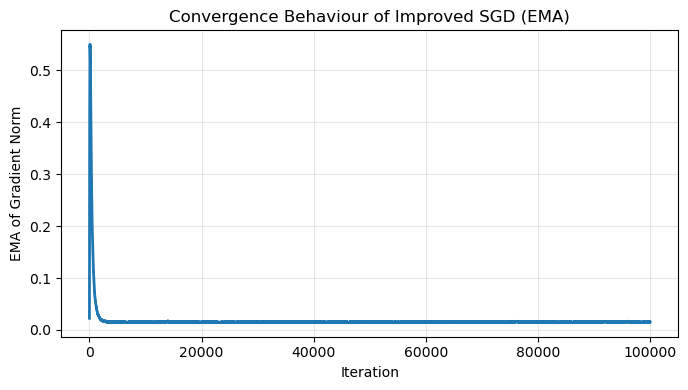

In [170]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(ema_history, linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("EMA of Gradient Norm")
plt.title("Convergence Behaviour of Improved SGD (EMA)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The EMA curve shows a sharp decline during the initial iterations, indicating rapid improvement in the parameter estimates as the algorithm moves toward the optimal region of the objective function.

After this initial phase, the EMA stabilizes at a low level and fluctuates slightly around a constant value. This behaviour is expected for stochastic gradient descent because mini-batch updates introduce random variation in the gradient.

Despite this stochastic noise, the overall stabilization of the EMA indicates that the algorithm has effectively converged to a neighborhood of the optimum. The small magnitude of the gradient norm suggests that further updates produce only minor adjustments to the parameter estimates.

This convergence behaviour confirms that the improved SGD implementation—combining feature scaling, a decaying learning rate, and EMA-based monitoring—successfully achieves stable optimization for the Fama–French three-factor regression model.

## Results and Comparison with the Normal Equation

The stochastic gradient descent algorithm produces coefficient estimates that closely match the closed-form least-squares solution obtained from the normal equation.

The estimated parameters from SGD are

$$
\hat{\beta}_{SGD}
=
[0.011116,\;1.551638,\;-0.551916,\;-0.739424],
$$

while the normal equation solution is

$$
\hat{\beta}_{NE}
=
[0.011146,\;1.554211,\;-0.550762,\;-0.739127].
$$

The absolute differences between the two estimators are

$$
|\hat{\beta}_{SGD}-\hat{\beta}_{NE}|
=
[3.06\times10^{-5},\;2.57\times10^{-3},\;1.15\times10^{-3},\;2.97\times10^{-4}],
$$

with a maximum absolute difference of

$$
\max |\Delta| = 0.002573.
$$

These results show that the improved stochastic gradient descent algorithm converges extremely close to the exact least-squares estimator. The very small deviations arise from the stochastic nature of mini-batch gradient updates and the finite iteration budget of $100{,}000$ iterations.

Overall, the close agreement confirms that the improved SGD implementation accurately approximates the closed-form solution while avoiding the premature stopping risk associated with the original tolerance-based `while` loop.

### Conclusion

The improved stochastic gradient descent implementation provides a reliable approach for estimating regression models when datasets become too large for direct matrix inversion. Although the Fama–French three-factor model in this exercise is small enough to be solved efficiently using the normal equation, the results demonstrate the practical advantages of modern optimization methods.

The close agreement between the SGD estimates and the closed-form solution shows that stochastic optimization can accurately recover the least-squares parameters while using iterative updates rather than expensive matrix operations.

From a practical perspective, this approach reflects how many real-world financial and machine learning models are estimated today. Large-scale asset pricing models, portfolio optimization systems, and financial risk models often involve millions of observations and high-dimensional features, where closed-form solutions become computationally inefficient or infeasible.

The improved implementation therefore illustrates several best-practice principles used in modern optimization:

- **fixed iteration budgets** to avoid unstable stopping conditions,
- **EMA-based monitoring** to interpret convergence in the presence of stochastic noise,
- and **feature scaling with adaptive learning rates** to stabilize gradient-based updates.

Together, these elements ensure that the stochastic gradient descent procedure converges reliably to the optimal parameter region. The results confirm that the improved SGD framework can successfully estimate the Fama–French model while providing a scalable optimization strategy suitable for large real-world financial datasets.